In [ ]:
# Core imports
import math
import random
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt

# NOTE: Per instructions, we only use matplotlib for plotting.
#       We also avoid specifying any custom colors explicitly.
#       Each chart is rendered in its own distinct figure.



## 1) MDP Definition

We represent an MDP with:
- `states`: iterable of hashable states
- `actions`: dictionary mapping state -> list of valid actions
- `P`: transition model `P[s][a] = list of (prob, next_state, reward, done)`
- `gamma`: discount factor in (0,1]

This general design lets you plug in *any* finite MDP.


In [ ]:

class MDP:
    def __init__(self, states, actions, P, gamma=0.99):
        """
        states: iterable of states (hashable)
        actions: dict: state -> list of actions
        P: dict: P[s][a] = list of (prob, s', r, done)
        gamma: float in (0, 1]
        """
        self.states = list(states)
        self.actions = {s: list(actions.get(s, [])) for s in states}
        self.P = P
        self.gamma = float(gamma)

    def is_terminal(self, s):
        """A state is terminal if it has no available actions."""
        return len(self.actions.get(s, [])) == 0



## 2) Policy Evaluation (Iterative)

Given a **policy** \(\pi(a\mid s)\), we compute its state-value function \(V^{\pi}\) by fixed-point iteration:

\[ V^{\pi}(s) \leftarrow \sum_{a} \pi(a\mid s) \sum_{s', r} p(s', r \mid s, a) \,[r + \gamma V^{\pi}(s')] \]

Stop when the change (max-norm) is below a small threshold `theta`.


In [ ]:

def policy_evaluation(mdp, policy, theta=1e-8, max_iters=10_000, track_history=False):
    """
    Evaluate a policy on the given MDP.

    Args:
        mdp: MDP instance
        policy: dict mapping state -> dict of action -> probability
        theta: small threshold for convergence (max-norm)
        max_iters: safety cap on iterations
        track_history: if True, collect and return the max-norm deltas per iteration

    Returns:
        V: dict mapping state -> value estimate
        deltas: list of max-norm diffs per iteration (if track_history)
    """
    V = {s: 0.0 for s in mdp.states}
    deltas = []

    for it in range(max_iters):
        delta = 0.0
        V_new = V.copy()
        for s in mdp.states:
            if mdp.is_terminal(s):
                V_new[s] = 0.0
                continue
            v = 0.0
            for a, pa in policy.get(s, {}).items():
                for (prob, s_next, r, done) in mdp.P[s][a]:
                    v += pa * prob * (r + mdp.gamma * V[s_next] * (0.0 if done else 1.0))
            V_new[s] = v
            delta = max(delta, abs(V_new[s] - V[s]))
        V = V_new
        if track_history:
            deltas.append(delta)
        if delta < theta:
            break
    return (V, deltas) if track_history else (V, None)



## 3) Policy Improvement

Given a value function \(V\), greedily improve the policy:

\[ \pi'(s) = \arg\max_{a} \sum_{s', r} p(s', r \mid s, a) \,[r + \gamma V(s')] \]

We return a **deterministic** policy (ties broken arbitrarily but consistently).


In [ ]:

def one_step_lookahead(mdp, V, s):
    """Compute action-values q(s,a) using current V."""
    q = {}
    for a in mdp.actions.get(s, []):
        total = 0.0
        for (prob, s_next, r, done) in mdp.P[s][a]:
            total += prob * (r + mdp.gamma * V[s_next] * (0.0 if done else 1.0))
        q[a] = total
    return q

def policy_improvement(mdp, V):
    """Return a greedy deterministic policy wrt V."""
    new_policy = {}
    stable = True
    for s in mdp.states:
        acts = mdp.actions.get(s, [])
        if len(acts) == 0:
            continue  # terminal
        q = one_step_lookahead(mdp, V, s)
        # Choose action(s) with max q
        best_q = max(q.values())
        best_actions = [a for a, val in q.items() if math.isclose(val, best_q, rel_tol=1e-12, abs_tol=1e-12)]
        # Make deterministic by picking the first best action (stable but arbitrary)
        best_a = best_actions[0]
        new_policy[s] = {a: (1.0 if a == best_a else 0.0) for a in acts}
    return new_policy



## 4) Policy Iteration

Alternate **policy evaluation** and **policy improvement** until the policy no longer changes.
This converges to an **optimal policy** for finite MDPs.


In [ ]:

def policy_iteration(mdp, theta=1e-8, max_eval_iters=10_000):
    """Run policy iteration. Returns (policy, V, history)."""
    # Start with an equiprobable random policy over available actions
    policy = {}
    for s in mdp.states:
        acts = mdp.actions.get(s, [])
        if acts:
            p = 1.0 / len(acts)
            policy[s] = {a: p for a in acts}

    history = []
    while True:
        # Evaluate current policy
        V, deltas = policy_evaluation(mdp, policy, theta=theta, max_iters=max_eval_iters, track_history=True)
        # Improve it
        new_policy = policy_improvement(mdp, V)
        history.append({
            "V": V.copy(),
            "policy": {s: new_policy.get(s, {}) for s in mdp.states},
            "deltas": deltas
        })
        # Check if policy is stable (no change)
        stable = True
        for s in policy:
            if s in new_policy:
                old_best = max(policy[s], key=policy[s].get)
                new_best = max(new_policy[s], key=new_policy[s].get)
                if old_best != new_best:
                    stable = False
                    break
        policy = new_policy
        if stable:
            break
    return policy, V, history



## 5) Example MDP: 4×4 Gridworld

- States: grid coordinates `(r, c)` where `r, c ∈ {0,1,2,3}`
- Actions: `['U','D','L','R']` except walls; terminals are top-left `(0,0)` and bottom-right `(3,3)`
- Reward: `-1` per step, `0` at terminals
- Transitions: deterministic move (stay in place if hitting boundary)

You can change `size`, `gamma`, and `step_reward` for experimentation.


In [ ]:

def build_gridworld(size=4, gamma=0.99, step_reward=-1.0):
    rows = cols = size
    states = [(r, c) for r in range(rows) for c in range(cols)]
    terminal_states = {(0, 0), (rows-1, cols-1)}
    actions = {}

    def valid(r, c):
        return 0 <= r < rows and 0 <= c < cols

    # Define actions per non-terminal state
    for s in states:
        if s in terminal_states:
            actions[s] = []
        else:
            actions[s] = ['U', 'D', 'L', 'R']

    # Transition model
    P = {s: {} for s in states}
    for s in states:
        r, c = s
        if s in terminal_states:
            continue
        for a in actions[s]:
            if a == 'U':
                nr, nc = r - 1, c
            elif a == 'D':
                nr, nc = r + 1, c
            elif a == 'L':
                nr, nc = r, c - 1
            else:  # 'R'
                nr, nc = r, c + 1
            if not valid(nr, nc):
                nr, nc = r, c  # bump into wall -> stay
            s_next = (nr, nc)
            done = s_next in terminal_states
            reward = 0.0 if done else step_reward
            # deterministic transition
            P[s].setdefault(a, []).append((1.0, s_next, reward, done))

    return MDP(states, actions, P, gamma=gamma), terminal_states, (rows, cols)

# Build default gridworld
mdp, terminal_states, shape = build_gridworld(size=4, gamma=0.99, step_reward=-1.0)



## 6) Run Policy Iteration


In [ ]:

optimal_policy, V_opt, hist = policy_iteration(mdp, theta=1e-9, max_eval_iters=10000)
print("Converged in", len(hist), "improvement step(s).")


Converged in 3 improvement step(s).



## 7) Visualizations

We include three plots:
1. **Convergence curve**: max-norm delta per evaluation iteration (last improvement round).
2. **Value function heatmap** over the grid.
3. **Policy arrows** drawn as a quiver plot on the grid.


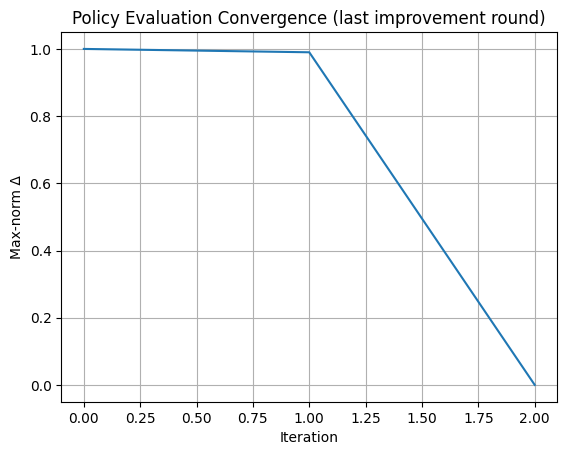

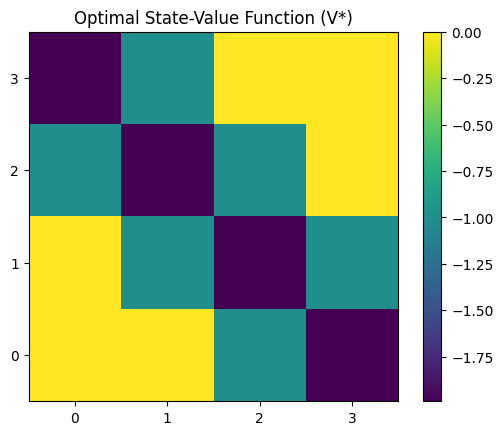

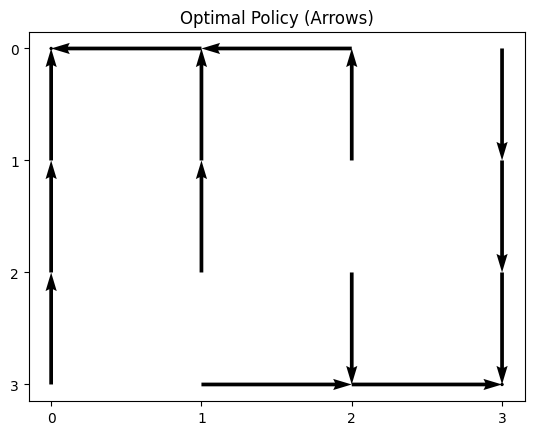

In [ ]:

def values_to_grid(V, shape):
    rows, cols = shape
    G = np.zeros((rows, cols), dtype=float)
    for (r, c), val in V.items():
        G[r, c] = val
    return G

def policy_to_arrows(policy, shape):
    """Map actions to arrow vectors for quiver plotting."""
    rows, cols = shape
    U = np.zeros((rows, cols))  # horizontal component
    V = np.zeros((rows, cols))  # vertical component
    # Action vectors: U (dx), V (dy) in image coordinates (row increases downward)
    vec = {'U': (0, -1), 'D': (0, 1), 'L': (-1, 0), 'R': (1, 0)}
    for (r, c), acts in policy.items():
        # deterministic policy assumed: pick action with prob 1.0
        if not acts:
            continue
        a = max(acts, key=acts.get)
        dx, dy = vec.get(a, (0, 0))
        U[r, c] = dx
        V[r, c] = dy
    return U, V

# 1) Convergence curve (last eval phase)
if hist and hist[-1].get("deltas"):
    plt.figure()
    plt.plot(hist[-1]["deltas"])
    plt.title("Policy Evaluation Convergence (last improvement round)")
    plt.xlabel("Iteration")
    plt.ylabel("Max-norm Δ")
    plt.grid(True)
    plt.show()

# 2) Value function heatmap
G = values_to_grid(V_opt, shape)
plt.figure()
plt.imshow(G, interpolation='nearest')
plt.title("Optimal State-Value Function (V*)")
plt.colorbar()
plt.xticks(range(G.shape[1]))
plt.yticks(range(G.shape[0]))
plt.gca().invert_yaxis()  # put row 0 at the top like a grid
plt.show()

# 3) Policy arrows
rows, cols = shape
U, W = policy_to_arrows(optimal_policy, shape)  # rename W to avoid shadowing values V
X, Y = np.meshgrid(np.arange(cols), np.arange(rows))
plt.figure()
plt.quiver(X, Y, U, W, angles='xy', scale_units='xy', scale=1)
plt.title("Optimal Policy (Arrows)")
plt.xticks(range(cols))
plt.yticks(range(rows))
plt.gca().invert_yaxis()
plt.show()



## 8) Inspect Optimal Policy & Values (Text Tables)


In [ ]:

def pretty_policy_table(policy, shape):
    rows, cols = shape
    table = []
    for r in range(rows):
        row = []
        for c in range(cols):
            acts = policy.get((r, c), {})
            if not acts:
                row.append("T")  # Terminal
            else:
                a = max(acts, key=acts.get)
                row.append(a)
        table.append(row)
    return table

def pretty_value_table(V, shape, precision=2):
    rows, cols = shape
    table = []
    for r in range(rows):
        row = []
        for c in range(cols):
            row.append(round(V[(r, c)], precision))
        table.append(row)
    return table

print("Policy (T = Terminal):")
for row in pretty_policy_table(optimal_policy, shape):
    print(row)

print("\nValues (rounded):")
for row in pretty_value_table(V_opt, shape):
    print(row)


Policy (T = Terminal):
['T', 'L', 'L', 'D']
['U', 'U', 'U', 'D']
['U', 'U', 'D', 'D']
['U', 'R', 'R', 'T']

Values (rounded):
[0.0, 0.0, -1.0, -1.99]
[0.0, -1.0, -1.99, -1.0]
[-1.0, -1.99, -1.0, 0.0]
[-1.99, -1.0, 0.0, 0.0]



## 9) (Optional) Try Your Own MDP

To try a custom MDP:
1. Define `states`, `actions`, and `P` as described in the `MDP` docstring.
2. Create `mdp = MDP(states, actions, P, gamma=...)`.
3. Run `policy_iteration(mdp)` and visualize with the helpers.

> Tip: For stochastic transitions, make `P[s][a]` contain multiple `(prob, s_next, r, done)` entries that sum to 1.0.
